# Finite Scalar Quantization — Visual Experiments

> **Goal:** See how rounding each channel to a fixed grid replaces the learned codebook — and why that makes collapse impossible.

## What we'll explore

| # | Experiment | Question answered |
|---|---|---|
| 1 | **Implicit grid** | What does the FSQ codebook look like compared to a learned VQ codebook? |
| 2 | **Bound + round** | How does $\lfloor L/2\rfloor\tanh$ then round turn a scalar into one of L levels? |
| 3 | **No dead levels** | Does every level on every channel get used, with no training tricks? |
| 4 | **Quality gap** | At equal codebook size, how much does the fixed grid cost vs an adaptive codebook? |

---
**Linked theory:** [research/06-finite-scalar-quantization.md](../research/06-finite-scalar-quantization.md)

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
plt.rcParams.update({
    'figure.dpi': 110,
    'font.size': 11,
    'axes.titlesize': 12,
    'axes.labelsize': 11,
    'figure.facecolor': 'white',
    'axes.facecolor': '#f8f9fa',
    'axes.grid': True,
    'grid.alpha': 0.35,
})


def fsq(z, levels):
    """Finite scalar quantization with odd level counts.

    z: (N, d) encoder outputs. levels: list of L_i (odd).
    returns (y, z_hat, tokens):
      y     = bounded continuous value half*tanh(z)
      z_hat = rounded grid value
      tokens = integer token in [0, prod(levels)) via mixed-radix
    """
    d = len(levels)
    y = np.zeros_like(z)
    idx = np.zeros((len(z), d), dtype=int)
    for i, L in enumerate(levels):
        half = L // 2
        y[:, i] = half * np.tanh(z[:, i])
        q = np.round(y[:, i])
        idx[:, i] = (q + half).astype(int)
    z_hat = idx - np.array([L // 2 for L in levels])
    radix = np.cumprod([1] + levels[:-1])
    tokens = (idx * radix).sum(1)
    return y, z_hat.astype(float), tokens


print('Setup complete.')

Setup complete.


---
## Experiment 1: Implicit grid

**Question:** VQ stores a learned table of codewords. FSQ stores nothing — its codebook is the Cartesian product of per-channel levels. What do the two codebooks look like side by side?

With levels $[5,5]$, FSQ's implicit codebook is a $5\times5=25$ point integer lattice. We contrast it with a learned VQ codebook of the same size (k-means, 25 codes) on identical data.

In [2]:
np.random.seed(1)

# encoder outputs: two elongated blobs
z = np.concatenate([
    np.array([1.2, 0.6]) + np.array([1.0, 0.3]) * np.random.randn(800, 2),
    np.array([-1.0, -1.0]) + np.array([0.3, 1.0]) * np.random.randn(800, 2),
])
levels = [5, 5]
y, z_hat, tokens = fsq(z, levels)

# VQ codebook of equal size on the bounded points y
K = int(np.prod(levels))
km = KMeans(n_clusters=K, n_init=3, random_state=0).fit(y)
print(f'FSQ implicit codebook = {levels[0]}x{levels[1]} = {K} grid points (0 stored params)')
print(f'distinct FSQ tokens actually used: {len(np.unique(tokens))}/{K}')

FSQ implicit codebook = 5x5 = 25 grid points (0 stored params)
distinct FSQ tokens actually used: 23/25


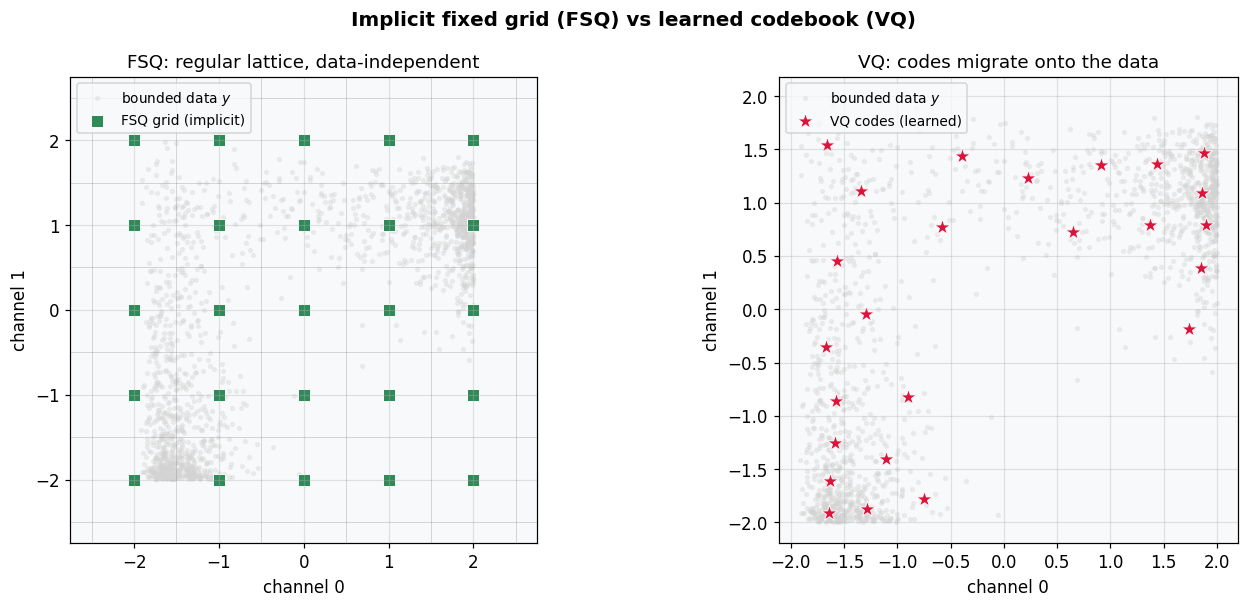

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5.6))
fig.suptitle('Implicit fixed grid (FSQ) vs learned codebook (VQ)', fontsize=13, fontweight='bold')

half = levels[0] // 2
gx, gy = np.meshgrid(np.arange(-half, half + 1), np.arange(-half, half + 1))

ax = axes[0]
ax.scatter(y[:, 0], y[:, 1], s=6, alpha=0.3, color='lightgray', label='bounded data $y$')
ax.scatter(gx.ravel(), gy.ravel(), c='seagreen', marker='s', s=70,
           edgecolor='white', linewidth=0.6, label='FSQ grid (implicit)')
for v in np.arange(-half - 0.5, half + 1):
    ax.axvline(v, color='gray', lw=0.4, alpha=0.5); ax.axhline(v, color='gray', lw=0.4, alpha=0.5)
ax.set_xlabel('channel 0'); ax.set_ylabel('channel 1')
ax.set_title('FSQ: regular lattice, data-independent')
ax.legend(loc='upper left', fontsize=9); ax.set_aspect('equal')

ax2 = axes[1]
ax2.scatter(y[:, 0], y[:, 1], s=6, alpha=0.3, color='lightgray', label='bounded data $y$')
ax2.scatter(km.cluster_centers_[:, 0], km.cluster_centers_[:, 1], c='crimson', marker='*',
            s=120, edgecolor='white', linewidth=0.6, label='VQ codes (learned)')
ax2.set_xlabel('channel 0'); ax2.set_ylabel('channel 1')
ax2.set_title('VQ: codes migrate onto the data')
ax2.legend(loc='upper left', fontsize=9); ax2.set_aspect('equal')

plt.tight_layout()
plt.show()

### What you see

1. **What the plot shows:** FSQ (left) places its 25 codes on a perfectly regular lattice that ignores where the data is — some grid points sit in empty space. VQ (right) moves its 25 learned codes onto the data clouds, leaving the empty regions bare.
2. **Why it looks this way:** FSQ's codebook is defined purely by the level structure $[5,5]$, so it is fixed before any data is seen. VQ's codebook is trained, so it adapts to the data distribution.
3. **Key takeaway:** FSQ trades adaptivity for simplicity — no table to store, no training to place codes, but a grid that does not concentrate resolution where the data lives.

---
## Experiment 2: Bound + round

**Question:** FSQ maps a real scalar to one of L levels with $f(z)=\lfloor L/2\rfloor\tanh(z)$ then round. What does that transfer function look like?

We plot the bounded continuous map and its rounded staircase for a single channel with L=5.

In [4]:
L = 5
half = L // 2
x = np.linspace(-4, 4, 1000)
f = half * np.tanh(x)
q = np.round(f)
print(f'L={L} -> levels {sorted(set(q.astype(int)))}')

L=5 -> levels [np.int64(-2), np.int64(-1), np.int64(0), np.int64(1), np.int64(2)]


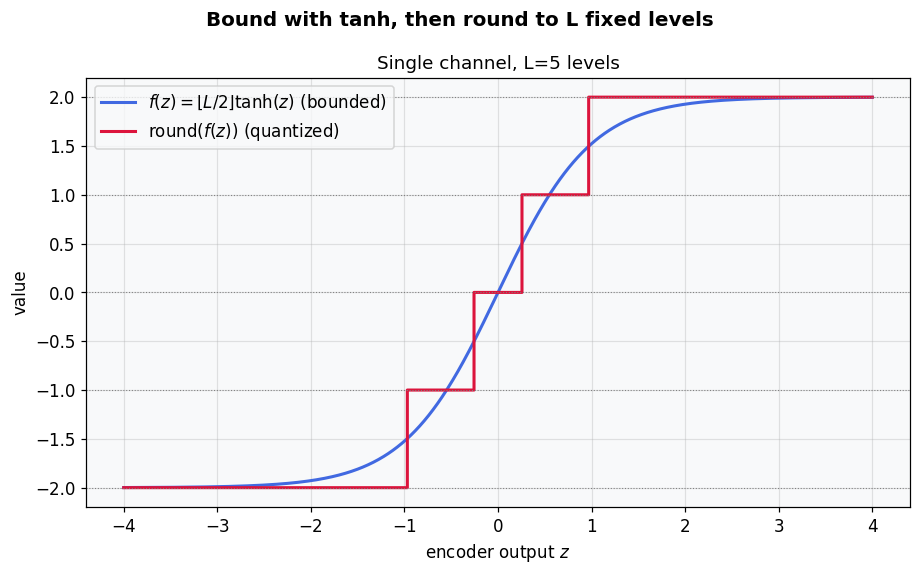

In [5]:
fig, ax = plt.subplots(figsize=(8.5, 5.3))
fig.suptitle('Bound with tanh, then round to L fixed levels', fontsize=13, fontweight='bold')

ax.plot(x, f, color='royalblue', lw=2, label='$f(z)=\\lfloor L/2\\rfloor\\tanh(z)$ (bounded)')
ax.plot(x, q, color='crimson', lw=2, drawstyle='steps-mid', label='round$(f(z))$ (quantized)')
for lvl in range(-half, half + 1):
    ax.axhline(lvl, color='gray', ls=':', lw=0.7)
ax.set_xlabel('encoder output $z$'); ax.set_ylabel('value')
ax.set_title(f'Single channel, L={L} levels')
ax.legend(loc='upper left')

plt.tight_layout()
plt.show()

### What you see

1. **What the plot shows:** The blue curve is a smooth S that saturates at ±2 (= $\lfloor 5/2\rfloor$). The red staircase snaps it to the five integer levels {−2,−1,0,1,2}, with flat treads and jumps at the half-integer boundaries.
2. **Why it looks this way:** tanh **bounds** the value into a finite range so the levels are guaranteed to cover it; round **discretizes** into exactly L bins. The flat treads are why round has zero gradient — hence FSQ, like VQ, relies on the straight-through estimator on the backward pass.
3. **Key takeaway:** This per-channel staircase is the entire quantizer — no codebook, no nearest-neighbour search, just bound and round.

---
## Experiment 3: No dead levels

**Question:** VQ fights codebook collapse with restarts and EMA. Does FSQ keep all its levels alive with none of that machinery?

We quantize data and count, for each channel, how often each level is used. Because tanh forces the encoder to spread across the bounded range, every level should be populated.

In [6]:
np.random.seed(3)

levels = [5, 7]
z = 1.5 * np.random.randn(5000, 2)
y, z_hat, tokens = fsq(z, levels)

level_idx = z_hat + np.array([L // 2 for L in levels])
usage_ch0 = np.bincount(level_idx[:, 0].astype(int), minlength=levels[0])
usage_ch1 = np.bincount(level_idx[:, 1].astype(int), minlength=levels[1])
print(f'channel 0 ({levels[0]} levels) usage: {usage_ch0}')
print(f'channel 1 ({levels[1]} levels) usage: {usage_ch1}')
print(f'dead levels: {(usage_ch0 == 0).sum() + (usage_ch1 == 0).sum()}')

channel 0 (5 levels) usage: [1340  905  636  896 1223]
channel 1 (7 levels) usage: [1100  742  495  442  480  732 1009]
dead levels: 0


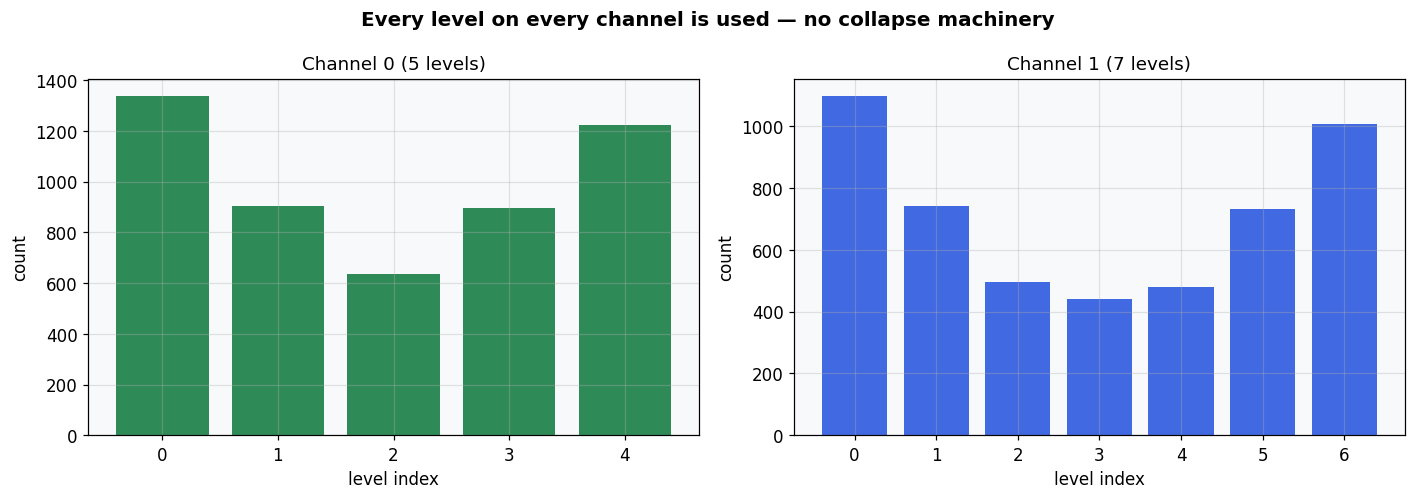

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.6))
fig.suptitle('Every level on every channel is used — no collapse machinery', fontsize=13, fontweight='bold')

ax = axes[0]
ax.bar(range(levels[0]), usage_ch0, color='seagreen')
ax.set_xlabel('level index'); ax.set_ylabel('count')
ax.set_title(f'Channel 0 ({levels[0]} levels)')

ax2 = axes[1]
ax2.bar(range(levels[1]), usage_ch1, color='royalblue')
ax2.set_xlabel('level index'); ax2.set_ylabel('count')
ax2.set_title(f'Channel 1 ({levels[1]} levels)')

plt.tight_layout()
plt.show()

### What you see

1. **What the plot shows:** Both channels populate all of their levels — 5 on the left, 7 on the right — with the bell-shaped emphasis on central levels that you'd expect from Gaussian-ish encoder outputs. Zero dead levels.
2. **Why it looks this way:** The tanh bound forces values into the finite level range, so the encoder cannot abandon levels by drifting off to infinity. There is no winner-takes-all `argmin` dynamic to starve any level — every level is reachable by construction.
3. **Key takeaway:** FSQ achieves high, stable utilization for free. This is the headline benefit: no commitment loss, no EMA, no restart, and no collapse to monitor.

---
## Experiment 4: Quality gap

**Question:** FSQ reportedly loses only ~0.5–3% to VQ. At equal codebook size, how big is the reconstruction gap, and where does it come from?

On the same bounded points, we compare FSQ (fixed grid) against VQ (k-means, equal number of codes) and measure quantization MSE across several codebook sizes.

In [8]:
np.random.seed(4)

# clustered data so an adaptive codebook has something to exploit
z = np.concatenate([
    np.array([1.5, 1.5]) + 0.4 * np.random.randn(2000, 2),
    np.array([-1.5, 0.5]) + 0.4 * np.random.randn(2000, 2),
    np.array([0.0, -1.8]) + 0.4 * np.random.randn(2000, 2),
])

level_options = [[3, 3], [5, 5], [7, 7], [9, 9]]
fsq_mse, vq_mse, sizes = [], [], []
for levels in level_options:
    y, z_hat, _ = fsq(z, levels)
    fsq_mse.append(((y - z_hat) ** 2).sum(1).mean())
    K = int(np.prod(levels)); sizes.append(K)
    km = KMeans(n_clusters=K, n_init=3, random_state=0).fit(y)
    d2 = ((y[:, None, :] - km.cluster_centers_[None]) ** 2).sum(-1)
    vq_mse.append(d2.min(1).mean())
print('codebook size:', sizes)
print('FSQ MSE      :', np.round(fsq_mse, 4))
print('VQ  MSE      :', np.round(vq_mse, 4))

codebook size: [9, 25, 49, 81]
FSQ MSE      : [0.0877 0.1265 0.1538 0.1709]
VQ  MSE      : [0.0165 0.022  0.0259 0.0271]


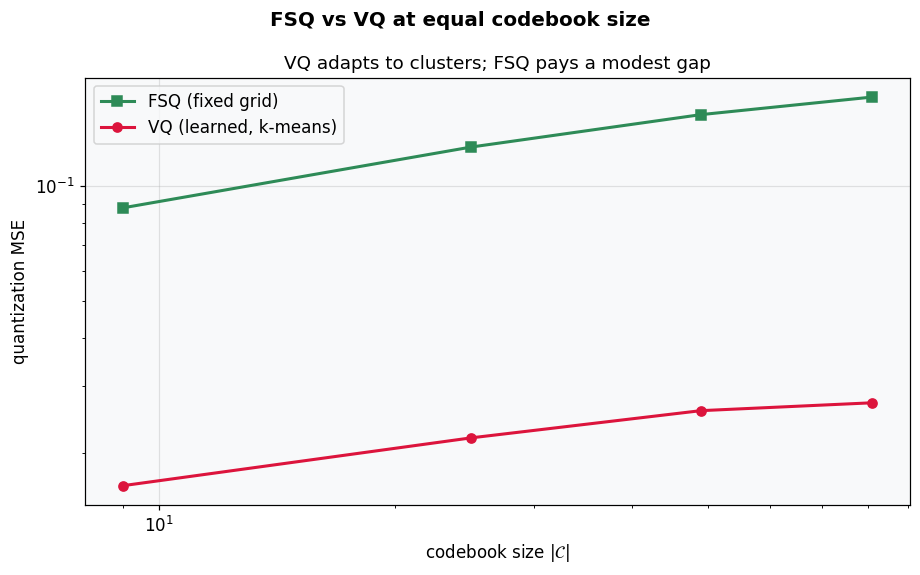

In [9]:
fig, ax = plt.subplots(figsize=(8.5, 5.3))
fig.suptitle('FSQ vs VQ at equal codebook size', fontsize=13, fontweight='bold')

ax.plot(sizes, fsq_mse, '-s', color='seagreen', lw=2, label='FSQ (fixed grid)')
ax.plot(sizes, vq_mse, '-o', color='crimson', lw=2, label='VQ (learned, k-means)')
ax.set_xlabel('codebook size $|\\mathcal{C}|$')
ax.set_ylabel('quantization MSE')
ax.set_xscale('log'); ax.set_yscale('log')
ax.set_title('VQ adapts to clusters; FSQ pays a modest gap')
ax.legend()

plt.tight_layout()
plt.show()

### What you see

1. **What the plot shows:** VQ (red) sits below FSQ (green) at every codebook size — the learned codebook reconstructs a bit better — but the gap is modest and both improve as the codebook grows.
2. **Why it looks this way:** VQ places codes inside the three clusters, so it spends resolution where the data is. FSQ's uniform grid wastes cells on the empty space between clusters, so its error is slightly higher. That wasted coverage is the source of the small quality gap.
3. **Key takeaway:** The fixed grid costs a little fidelity, but in exchange FSQ removes collapse and all the VQ training machinery — often a worthwhile trade for large tokenizers.

---
## Summary

| Experiment | Key insight |
|---|---|
| 1. Implicit grid | FSQ's codebook is a fixed Cartesian lattice with zero stored parameters; VQ's is learned and data-adaptive. |
| 2. Bound + round | tanh bounds, round discretizes into L levels; the flat treads still need a straight-through estimator. |
| 3. No dead levels | The bound forces full coverage, so every level is used with no restarts, EMA, or commitment loss. |
| 4. Quality gap | The uniform grid wastes cells in empty space, costing a small (~0.5–3%) fidelity gap vs adaptive VQ. |

### Connection to the broader theory

FSQ is the minimalist end of the quantizer spectrum: it removes the learned codebook and, with it, [codebook collapse](../research/04-codebook-collapse.md), [commitment loss](../research/02-commitment-loss.md), and [EMA updates](../research/03-ema-codebook-update.md). With FSQ, [Residual VQ](../research/05-residual-vq.md), and plain [VQ](../research/01-vector-quantization.md) covered, the quantizer toolbox is complete. The rest of Tier 9 uses their *output* — discrete token sequences — to drive dynamics: the **tokenized world model**, then the large-scale systems GAIA-1 and Genie.